In [3]:
# ==========================================
# [Cell 1] 环境配置与物理拓扑
# ==========================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前炼丹炉核心算力来源: {device}")

branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

R = branch_data[:, 2]
X = branch_data[:, 3]
num_nodes = 33
y_bus = np.zeros((num_nodes, num_nodes), dtype=complex)

for i in range(len(branch_data)):
    f = int(branch_data[i, 0] - 1)
    t = int(branch_data[i, 1] - 1)
    r = branch_data[i, 2]
    x = branch_data[i, 3]
    
    z_line = r + 1j * x
    y_line = 1 / z_line
    y_bus[f, f] += y_line
    y_bus[t, t] += y_line
    y_bus[f, t] = -y_line
    y_bus[t, f] = -y_line

G_tensor = torch.tensor(y_bus.real, dtype=torch.float32).to(device)
B_tensor = torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

🚀 当前炼丹炉核心算力来源: cuda


In [4]:
# ==========================================
# [Cell 2] 核心函数与类定义
# ==========================================
obs_indices = [0,5,12,21,30]

def apply_blind_zone(batch_x ,obs_indices , mean_t , scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[: , idx] = batch_x[: , idx]
        masked_x[:, idx + 33] = batch_x[:, idx + 33]
    return masked_x

def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_matrix = torch.cos(delta_theta)
    sin_matrix = torch.sin(delta_theta)
    p_term = G_t * cos_matrix + B_t * sin_matrix
    q_term = G_t * sin_matrix - B_t * cos_matrix
    sum_p = torch.sum(V_pred.unsqueeze(1) * p_term, dim=2)
    sum_q = torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)
    P_calc = V_pred * sum_p
    Q_calc = V_pred * sum_q
    return P_calc, Q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
        )
        self.output_layers = nn.Linear(256, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)
        #来个标准值 残差学习
        Vm_pred = output[:, :33] * 0.1+ 1.0
        theta_pred = output[:, 33:] * 0.01+ 0.0
        Vm_pred[: , 0] = 1.0
        theta_pred[: , 0] = 0.0
        return Vm_pred, theta_pred

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B , obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G = G
        self.B = B
        self.mse_tool = nn.MSELoss()
        self.obs_idx = obs_idx

    def forward(self, V_pred, theta_pred, P_real_target , Q_real_target , V_real , p_weight, obs_weight=500000):
        P_calc , Q_calc= calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        P_loss = self.mse_tool(P_calc, P_real_target)
        Q_loss = self.mse_tool(Q_calc, Q_real_target)
        V_obs_pred = V_pred[: , self.obs_idx]
        V_obs_real = V_real[: , self.obs_idx]
        obs_loss = torch.sum((V_obs_pred - V_obs_real)**2)
        
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.1)
        
        # 增加 obs_weight 控制，方便消融实验
        return (
            p_weight * (P_loss + Q_loss) + 
            1000 * torch.mean(penalty_low + penalty_high) + 
            obs_weight * obs_loss
        )

class MyDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [5]:
# ==========================================
# [Cell 3] 数据读取与预处理
# ==========================================
df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]

data_3d = raw_data.reshape(m, 33, 4)
X_3d = data_3d[:, :, 0:2]
Y_3d = data_3d[:, :, 2:]
# 脱水：兆瓦变标幺值
P_real_pu = data_3d[:, :, 0].copy() / 100.0
Q_real_pu = data_3d[:, :, 1].copy() / 100.0
X_3d = X_3d.reshape(m, 66)
Y_3d = Y_3d.reshape(m, 66)

ssl = StandardScaler()
X_3d = ssl.fit_transform(X_3d)
mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
V_real_pu = data_3d[: , : , 2].copy()

PQV_target_up = np.concatenate([P_real_pu, Q_real_pu , V_real_pu], axis=1)
X_tensor = torch.tensor(X_3d, dtype=torch.float32).to(device)
PQ_target_tensor = torch.tensor(PQV_target_up,dtype=torch.float32).to(device)

train_dataset = MyDataset(X_tensor, PQ_target_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(f"✅ 数据装载完毕！共 {m} 条样本。")

✅ 数据装载完毕！共 50000 条样本。


In [4]:
# ==========================================
# [Cell 4] 消融实验一：纯数据驱动 (Pure Data-driven)
# ==========================================
print("🚀 开始实验一：纯数据驱动 (屏蔽物理约束 p_weight = 0)...")
max_epoch_ablation = 100 # 对照组跑100轮足够看出差距
model_case1 = PowerGridPINN(input_dim=66).to(device)

with torch.no_grad():
    model_case1.output_layers.bias[:33].fill_(-0.5)

pinn_loss_case1 = PowerPINNLoss(G_tensor, B_tensor , obs_indices)
optimizer_1 = torch.optim.Adam(model_case1.parameters(), lr=0.001)
scheduler_1 = torch.optim.lr_scheduler.StepLR(optimizer_1, step_size=30, gamma=0.5)

for epoch in range(max_epoch_ablation):
    model_case1.train()
    for batch_x , batch_all_targets in train_loader:
        optimizer_1.zero_grad()
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, obs_indices , mean_tensor, scale_tensor)
        V_guess , theta_guess = model_case1(mask_x)
        
        # ⚠️ 核心：强行设置 p_weight = 0，关闭物理约束
        loss = pinn_loss_case1(V_guess, theta_guess, real_p, real_q , real_v , p_weight=0, obs_weight=500000)
        loss.backward()
        optimizer_1.step()
    scheduler_1.step()

model_case1.eval()
with torch.no_grad():
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000,:,2]
    masked_test_X = apply_blind_zone(test_X, obs_indices , mean_tensor, scale_tensor)
    pred_Vm_1 , _ = model_case1(masked_test_X)
    mae_case1 = np.mean(np.abs(pred_Vm_1.cpu().numpy() - real_Vm))
    print(f"📊 [Case 1] 纯数据驱动 全网平均误差: {mae_case1:.6f} p.u.")

🚀 开始实验一：纯数据驱动 (屏蔽物理约束 p_weight = 0)...
📊 [Case 1] 纯数据驱动 全网平均误差: 0.022087 p.u.


In [5]:
# ==========================================
# [Cell 5] 消融实验二：纯物理驱动 (Pure Physics-driven)
# ==========================================
print("🚀 开始实验二：纯物理驱动 (屏蔽观测蓝星 obs_weight = 0)...")
model_case2 = PowerGridPINN(input_dim=66).to(device)

with torch.no_grad():
    model_case2.output_layers.bias[:33].fill_(-0.5)

pinn_loss_case2 = PowerPINNLoss(G_tensor, B_tensor , obs_indices)
optimizer_2 = torch.optim.Adam(model_case2.parameters(), lr=0.001)
scheduler_2 = torch.optim.lr_scheduler.StepLR(optimizer_2, step_size=30, gamma=0.5)

for epoch in range(max_epoch_ablation):
    model_case2.train()
    for batch_x , batch_all_targets in train_loader:
        optimizer_2.zero_grad()
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, obs_indices , mean_tensor, scale_tensor)
        V_guess , theta_guess = model_case2(mask_x)
        
        # ⚠️ 核心：强行设置 obs_weight = 0，保留物理方程 p_weight=5000
        loss = pinn_loss_case2(V_guess, theta_guess, real_p, real_q , real_v , p_weight=5000, obs_weight=0)
        loss.backward()
        optimizer_2.step()
    scheduler_2.step()

model_case2.eval()
with torch.no_grad():
    pred_Vm_2 , _ = model_case2(masked_test_X)
    mae_case2 = np.mean(np.abs(pred_Vm_2.cpu().numpy() - real_Vm))
    print(f"📊 [Case 2] 纯物理驱动 全网平均误差: {mae_case2:.6f} p.u.")

🚀 开始实验二：纯物理驱动 (屏蔽观测蓝星 obs_weight = 0)...
📊 [Case 2] 纯物理驱动 全网平均误差: 0.051794 p.u.


🚀 开始实验三：完整版 R-PINN (物理 + 数据双驱动)...
Epoch 0 | Avg Loss: 75463.018545 | LR: 0.001
Epoch 10 | Avg Loss: 815.773579 | LR: 0.001
Epoch 20 | Avg Loss: 762.957650 | LR: 0.001
Epoch 30 | Avg Loss: 763.514320 | LR: 0.001
Epoch 40 | Avg Loss: 719.349857 | LR: 0.0005
Epoch 50 | Avg Loss: 6511.756740 | LR: 0.0005
Epoch 60 | Avg Loss: 1099.386284 | LR: 0.0005
Epoch 70 | Avg Loss: 1104.403431 | LR: 0.0005
Epoch 80 | Avg Loss: 1079.846330 | LR: 0.00025
Epoch 90 | Avg Loss: 1083.381510 | LR: 0.00025
Epoch 100 | Avg Loss: 1084.589937 | LR: 0.00025
Epoch 110 | Avg Loss: 1082.727888 | LR: 0.00025
Epoch 120 | Avg Loss: 1073.574212 | LR: 0.000125
Epoch 130 | Avg Loss: 1074.435280 | LR: 0.000125
Epoch 140 | Avg Loss: 1074.365048 | LR: 0.000125
🏆 [Case 3] 完整 R-PINN 全网平均误差: 0.005110 p.u.


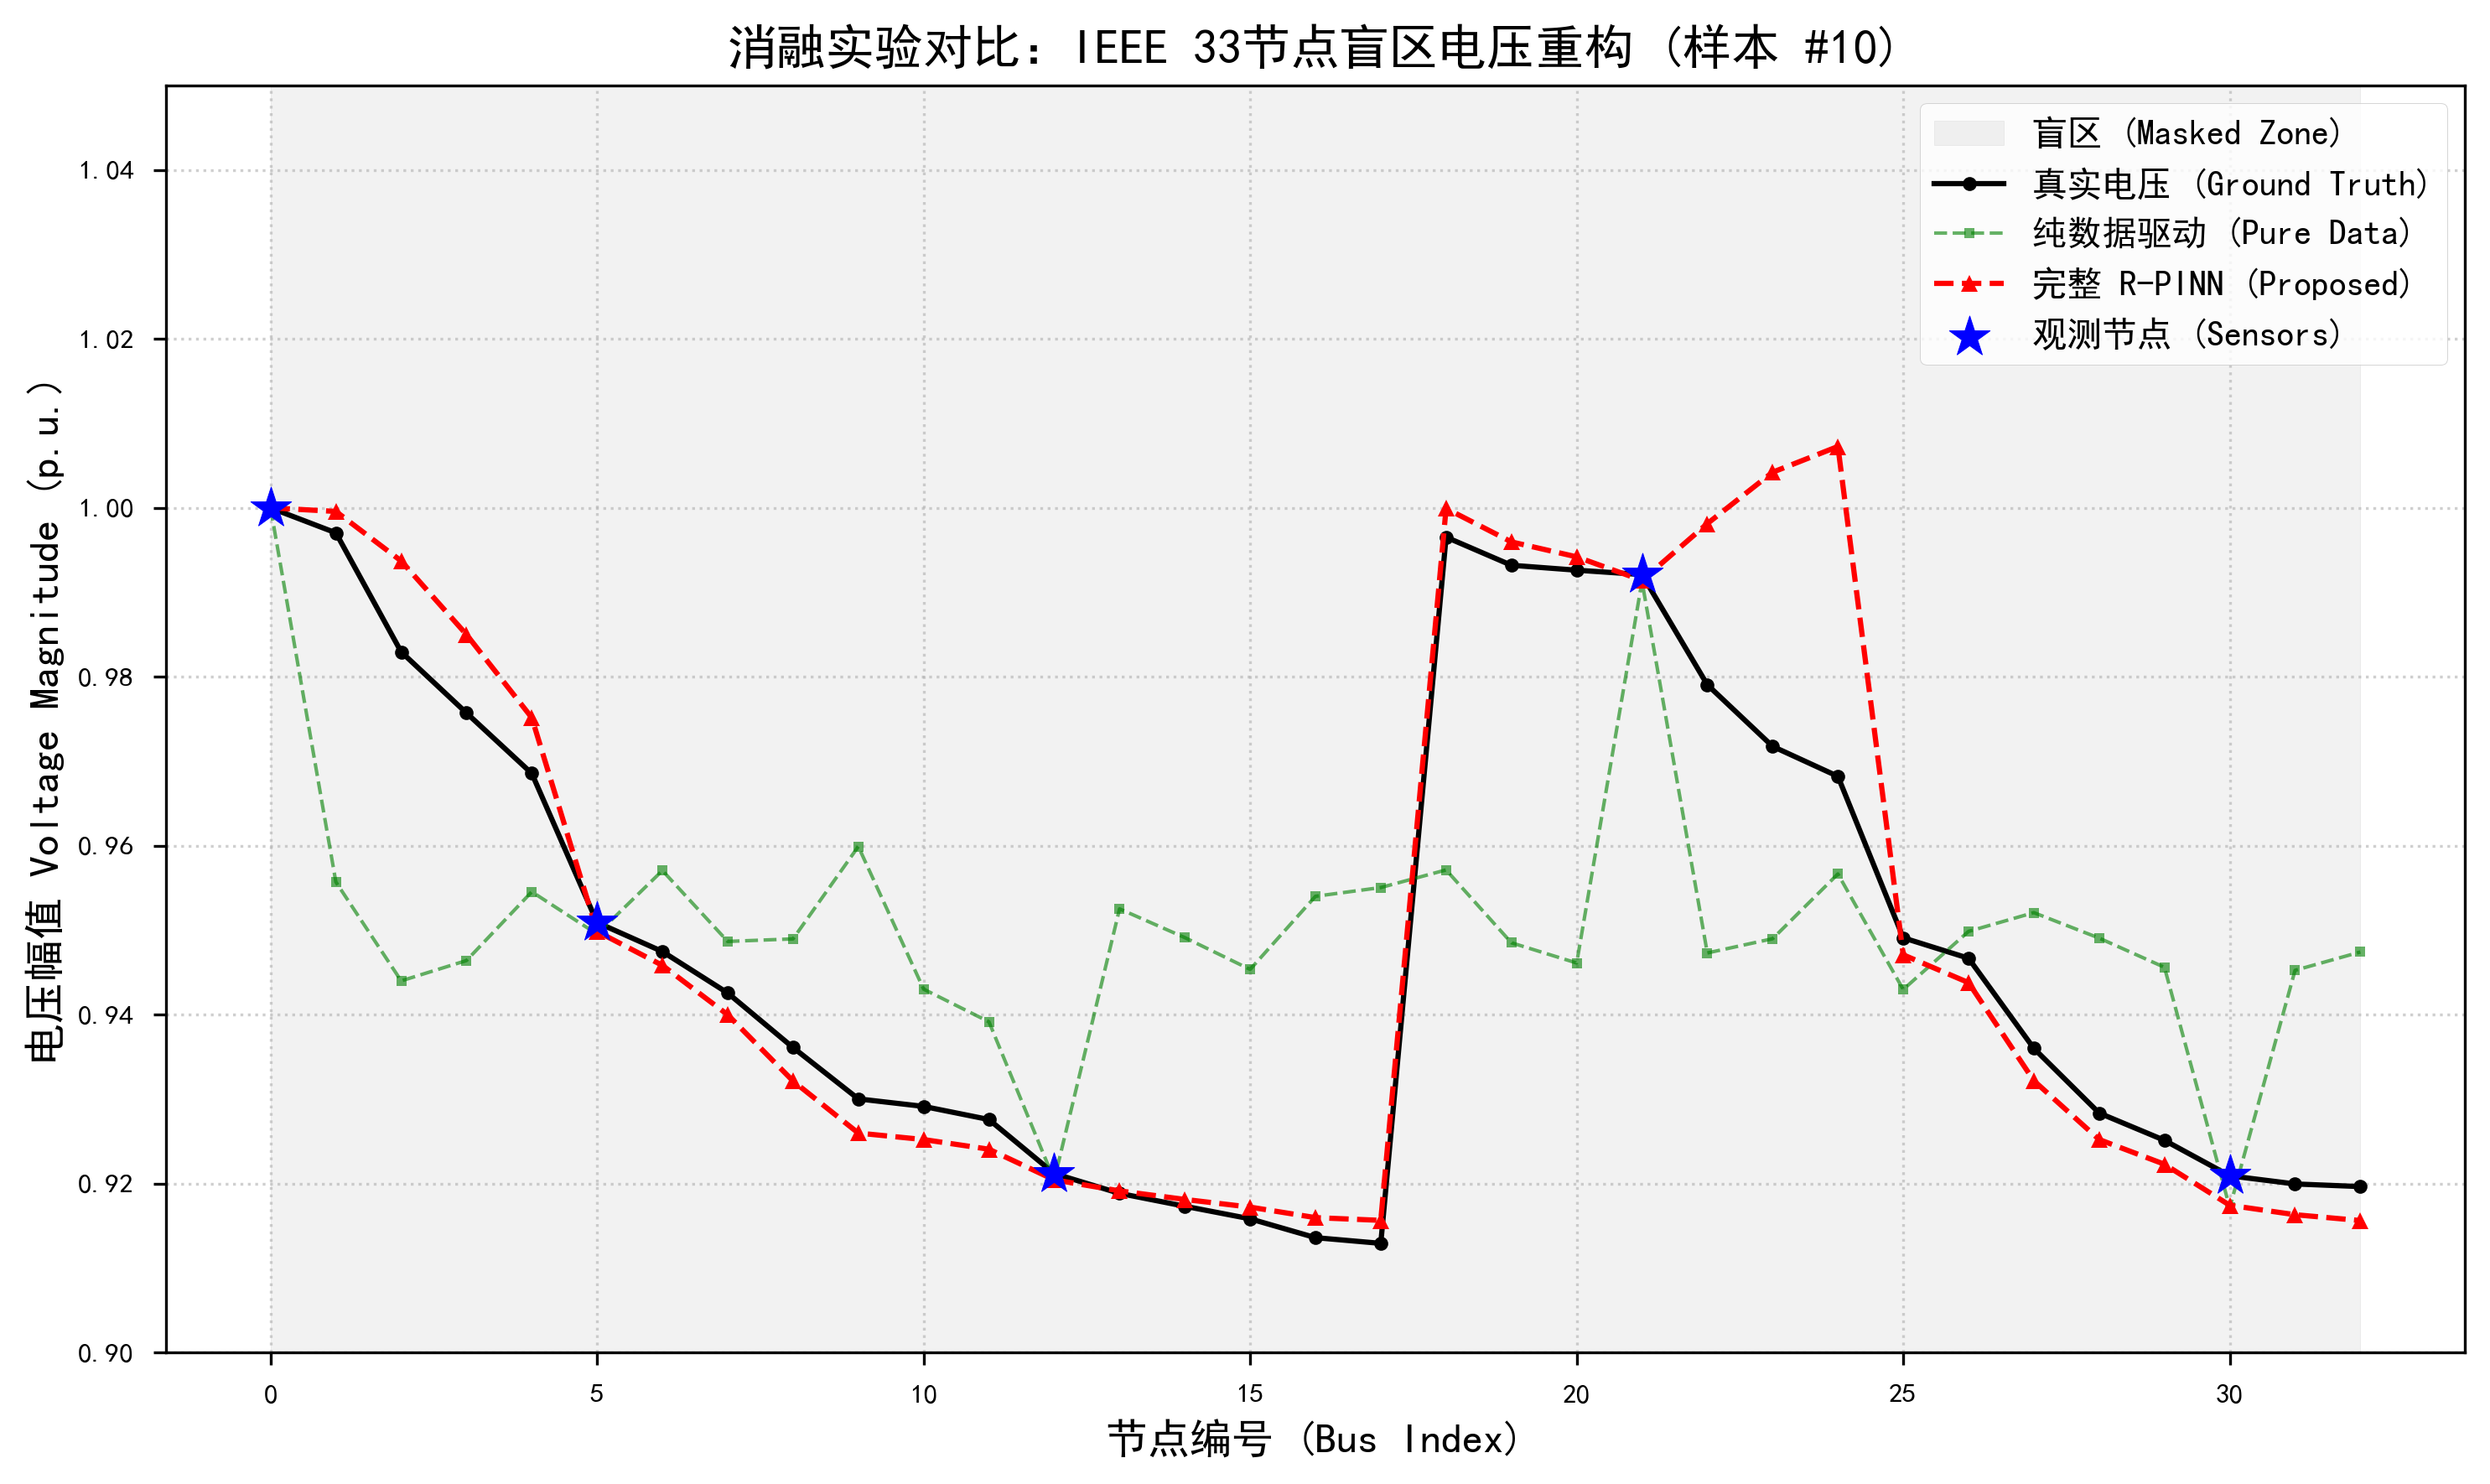


📊 --- 终极对账单 (R-PINN) ---
节点    | 真实值 (Actual) | 预测值 (Pred)   | 偏差 (Bias)
-------------------------------------------------------
0  ★ | 1.000000 | 1.000000 | +0.000000
1     | 0.997044 | 0.999579 | +0.002535
2     | 0.982948 | 0.993712 | +0.010763
3     | 0.975715 | 0.984997 | +0.009282
4     | 0.968559 | 0.975159 | +0.006600
5  ★ | 0.950914 | 0.949853 | -0.001062
6     | 0.947471 | 0.945834 | -0.001637
7     | 0.942562 | 0.939983 | -0.002579
8     | 0.936108 | 0.932145 | -0.003964
9     | 0.930026 | 0.925978 | -0.004048
10    | 0.929137 | 0.925212 | -0.003925
11    | 0.927582 | 0.924067 | -0.003515
12 ★ | 0.921186 | 0.920443 | -0.000743
13    | 0.918840 | 0.919134 | +0.000294
14    | 0.917316 | 0.918123 | +0.000807
15    | 0.915827 | 0.917212 | +0.001385
16    | 0.913596 | 0.915967 | +0.002371
17    | 0.912923 | 0.915646 | +0.002722
18    | 0.996535 | 0.999932 | +0.003397
19    | 0.993205 | 0.995969 | +0.002764
20    | 0.992621 | 0.994199 | +0.001578
21 ★ | 0.992102 | 0.991416 | -0.0

In [6]:
# ==========================================
# [Cell 6] 战神完整版 (Proposed R-PINN)
# ==========================================
print("🚀 开始实验三：完整版 R-PINN (物理 + 数据双驱动)...")
max_epoch = 150
model_case3 = PowerGridPINN(input_dim=66).to(device)

with torch.no_grad():
    model_case3.output_layers.bias[:33].fill_(-0.5)

pinn_loss_case3 = PowerPINNLoss(G_tensor, B_tensor , obs_indices)
optimizer_3 = torch.optim.Adam(model_case3.parameters(), lr=0.001)
scheduler_3 = torch.optim.lr_scheduler.StepLR(optimizer_3, step_size=40, gamma=0.5) 

for epoch in range(max_epoch):
    running_loss = 0.0
    p_weight = 1000 if epoch < 50 else 5000
    model_case3.train()
    
    for batch_x , batch_all_targets in train_loader:
        optimizer_3.zero_grad()
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, obs_indices , mean_tensor, scale_tensor)
        V_guess , theta_guess = model_case3(mask_x)
        
        # 完整实力：物理拉力与数据锚点的结合
        loss = pinn_loss_case3(V_guess, theta_guess, real_p, real_q , real_v , p_weight, obs_weight=500000)
        loss.backward()
        optimizer_3.step()
        running_loss += loss.item()
    
    scheduler_3.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Avg Loss: {running_loss/len(train_loader):.6f} | LR: {optimizer_3.param_groups[0]['lr']}")

model_case3.eval()
with torch.no_grad():
    pred_Vm_3 , pred_theta_3 = model_case3(masked_test_X)
    pred_Vm_np = pred_Vm_3.cpu().numpy()
    error_Vm = np.abs(pred_Vm_np - real_Vm)
    mae_case3 = np.mean(error_Vm)
    
print(f"🏆 [Case 3] 完整 R-PINN 全网平均误差: {mae_case3:.6f} p.u.")

# ==========================================
# 画图与对账
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx,:,2]

# 获取三个模型的单样本预测结果
with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_pred_1, _ = model_case1(masked_input)
    v_pred_2, _ = model_case2(masked_input)
    v_pred_3, _ = model_case3(masked_input)
    v_pred_1 = v_pred_1.cpu().numpy().flatten()
    v_pred_2 = v_pred_2.cpu().numpy().flatten()
    v_pred_3 = v_pred_3.cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 6), dpi=300) 
plt.axvspan(0, 32, color='gray', alpha=0.1, label='盲区 (Masked Zone)')
plt.plot(nodes, v_true, 'k-o', label='真实电压 (Ground Truth)', markersize=4, linewidth=1.5)
plt.plot(nodes, v_pred_1, 'g--s', label='纯数据驱动 (Pure Data)', markersize=3, linewidth=1.0, alpha=0.6)
plt.plot(nodes, v_pred_3, 'r--^', label='完整 R-PINN (Proposed)', markersize=5, linewidth=1.5)
plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=150, zorder=5, label='观测节点 (Sensors)')
plt.title(f"消融实验对比：IEEE 33节点盲区电压重构 (样本 #{sample_idx})", fontsize=14)
plt.xlabel("节点编号 (Bus Index)", fontsize=12)
plt.ylabel("电压幅值 Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('ablation_study_result.png') 
plt.show()

print("\n📊 --- 终极对账单 (R-PINN) ---")
print(f"{'节点':<5} | {'真实值 (Actual)':<12} | {'预测值 (Pred)':<12} | {'偏差 (Bias)'}")
print("-" * 55)
for i in range(33):
    bias = v_pred_3[i] - v_true[i]
    tag = "★" if i in obs_indices else "  " 
    print(f"{i:<2} {tag} | {v_true[i]:.6f} | {v_pred_3[i]:.6f} | {bias:+.6f}")
print("-" * 55)

🔥 启动消融实验：纯数据驱动基线 (仅靠 5 个观测点硬猜)...
Epoch 0   | Obs MSE Loss: 0.00005129
Epoch 30  | Obs MSE Loss: 0.00000200
Epoch 60  | Obs MSE Loss: 0.00000191
Epoch 90  | Obs MSE Loss: 0.00000189
Epoch 120 | Obs MSE Loss: 0.00000188

📊 【消融实验结论】
📊 纯数据驱动全网 MAE: 0.022089 p.u.
📊 你的 R-PINN MAE (参考): 0.005100 p.u.


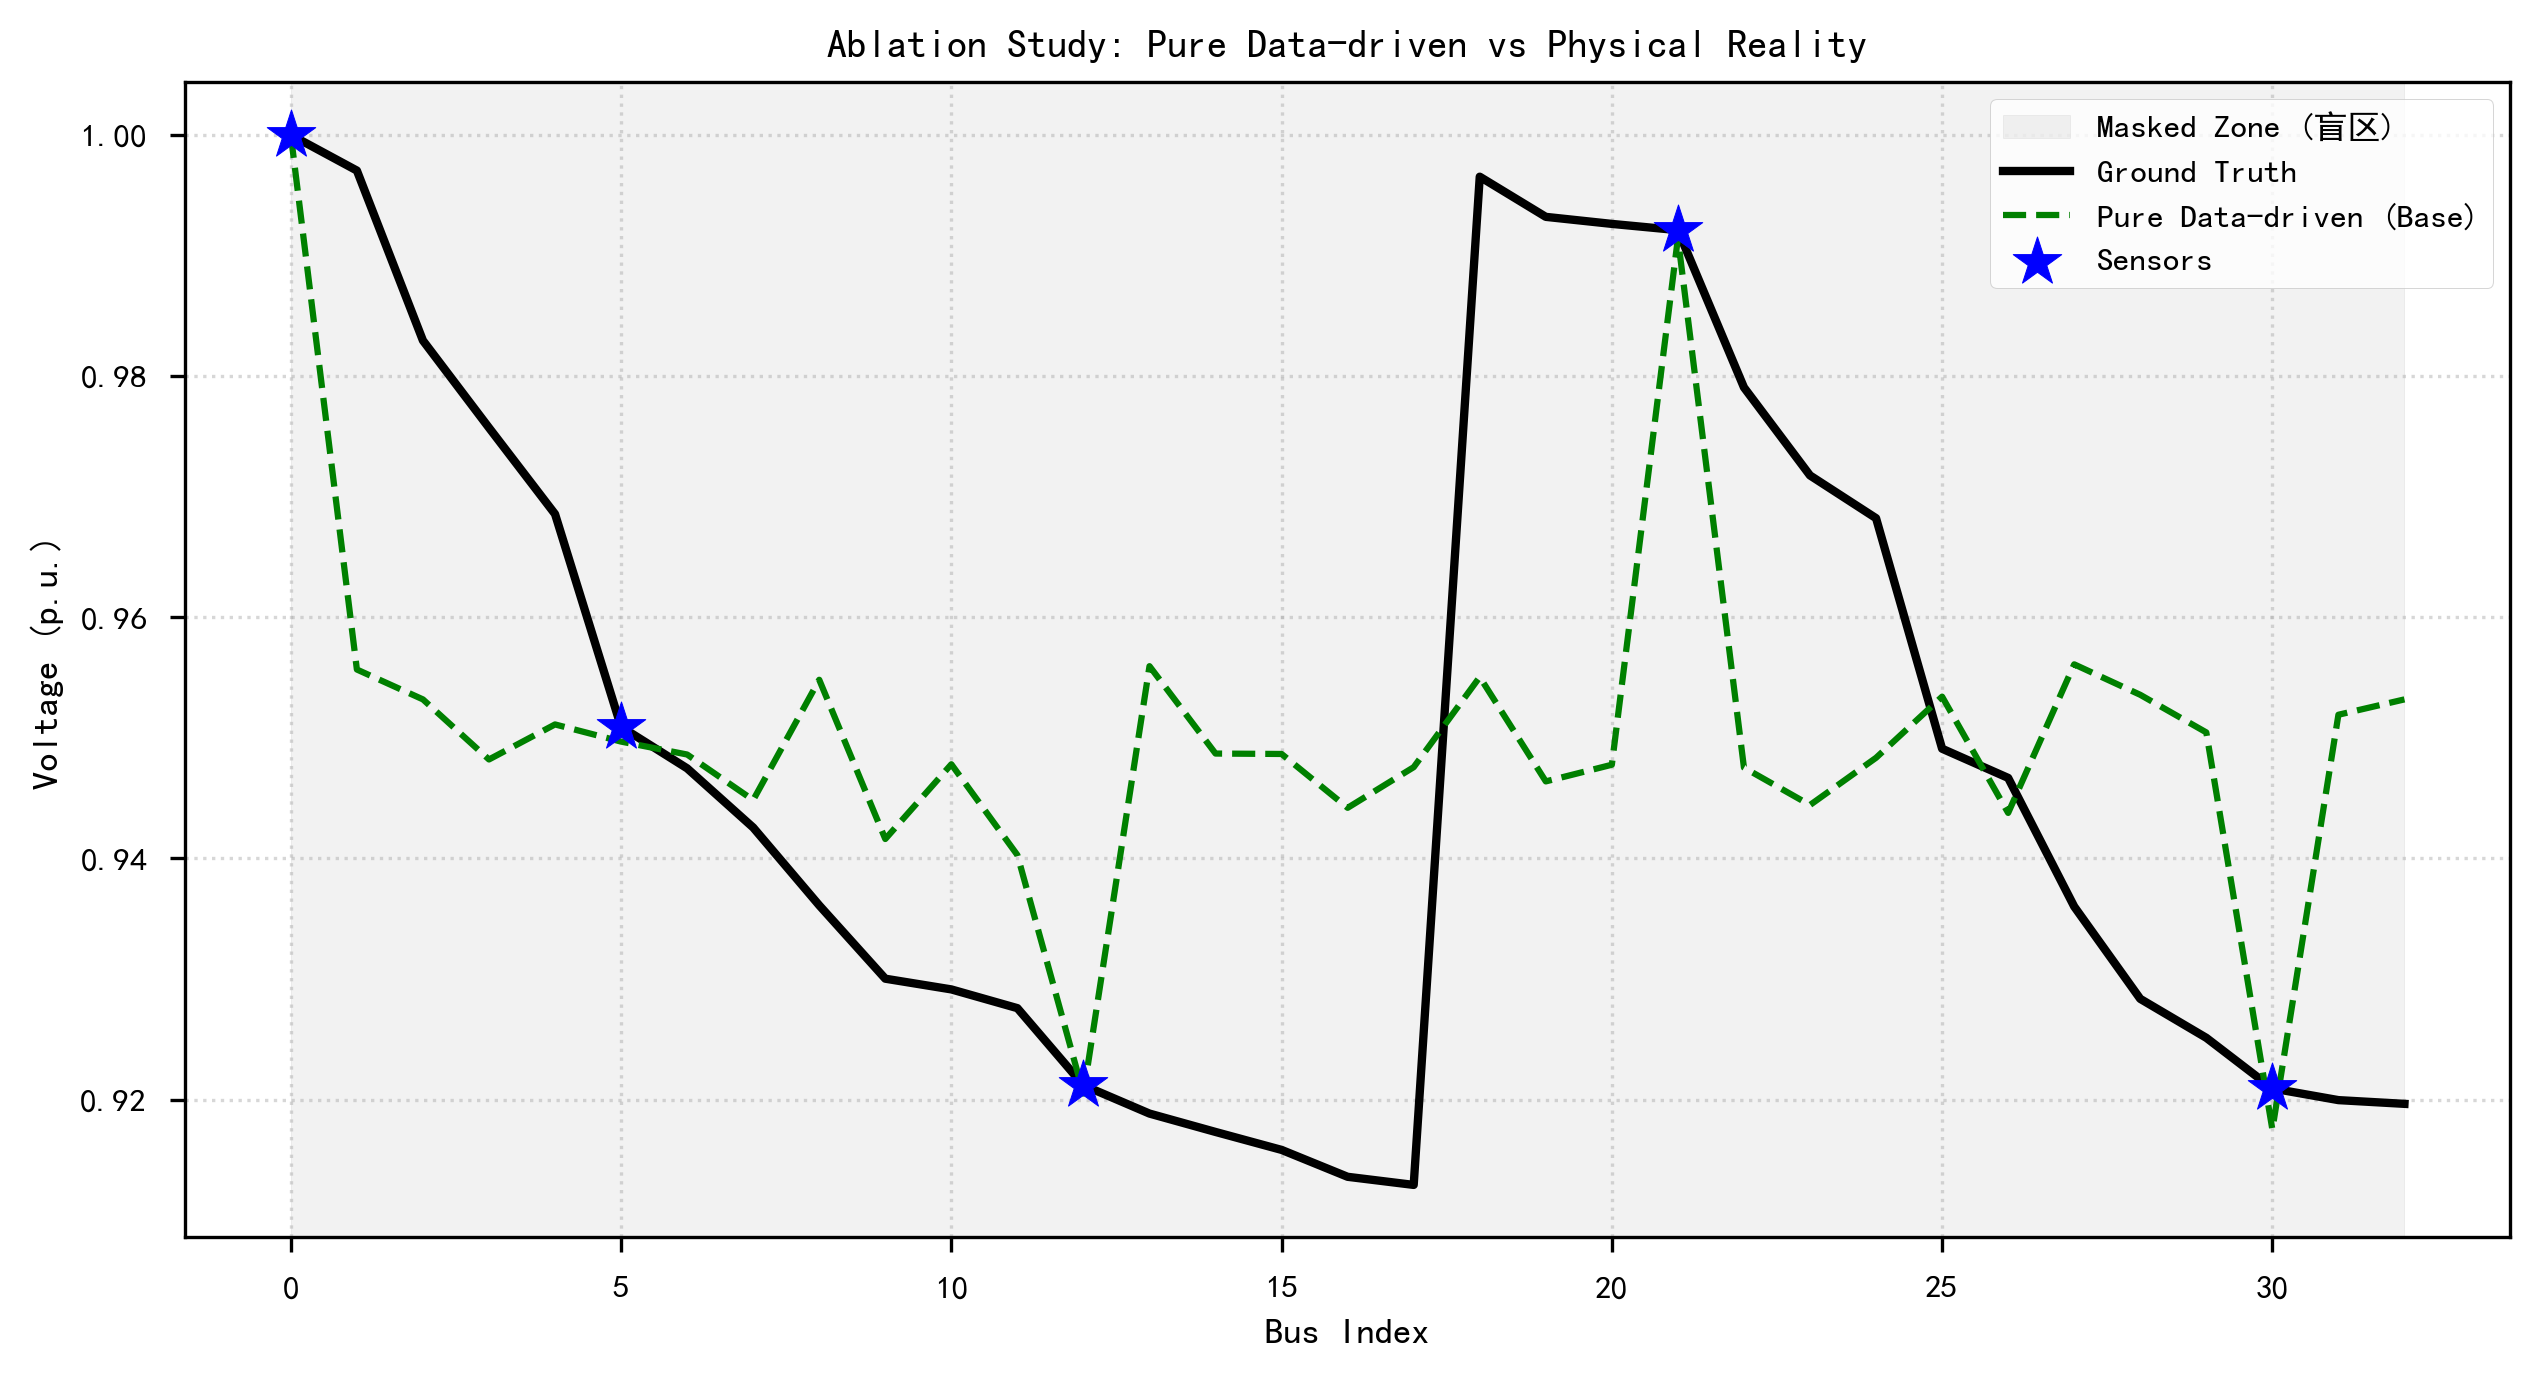

In [6]:
# ==========================================
# [Cell 7] 消融实验：纯数据驱动 (仅观测点最小二乘拟合)
# ==========================================
print("🔥 启动消融实验：纯数据驱动基线 (仅靠 5 个观测点硬猜)...")

# 1. 实例化一个全新的模型（复用 Cell 3 的架构，但不携带 PINN 的记忆）
model_pure_data = PowerGridPINN(input_dim=66).to(device)

# 2. 同样的初始化逻辑：让 AI 从跌落区开始找答案
with torch.no_grad():
    model_pure_data.output_layers.bias[:33].fill_(-0.5)

# 3. 优化器与损失函数 (注意：这里只有 MSE，没有任何物理约束)
optimizer_data = torch.optim.Adam(model_pure_data.to(device).parameters(), lr=0.001)
scheduler_data = torch.optim.lr_scheduler.StepLR(optimizer_data, step_size=40, gamma=0.5)
criterion_mse = nn.MSELoss()

# 4. 训练循环 (同样跑 150 轮，保证对比公平)
for epoch in range(150):
    running_loss_data = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_data.zero_grad()
        
        # 获取真实电压标签
        real_v = batch_all_targets[:, 66:] 
        
        # 应用盲区掩码 (复用 Cell 3 的函数)
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型预测
        V_guess, _ = model_pure_data(mask_x)
        
        # 【关键】：只计算 5 个观测节点的最小二乘误差
        # 这就是 DeepSeek 说的“纯数据驱动”——盲区完全靠模型瞎猜
        loss = criterion_mse(V_guess[:, obs_indices], real_v[:, obs_indices])
        
        loss.backward()
        optimizer_data.step()
        running_loss_data += loss.item()
        
    scheduler_data.step()
    if epoch % 30 == 0:
        print(f"Epoch {epoch:<3} | Obs MSE Loss: {running_loss_data/len(train_loader):.8f}")

# 5. 性能对账与结果可视化
model_pure_data.eval()
with torch.no_grad():
    # 测试前 1000 个样本的全网 MAE
    test_X_all = X_tensor[:1000]
    test_V_real = PQ_target_tensor[:1000, 66:]
    masked_test_X = apply_blind_zone(test_X_all, obs_indices, mean_tensor, scale_tensor)
    
    pred_V_pure, _ = model_pure_data(masked_test_X)
    pred_V_pure_np = pred_V_pure.cpu().numpy()
    real_V_np = test_V_real.cpu().numpy()

mae_pure = np.mean(np.abs(pred_V_pure_np - real_V_np))
print("\n" + "="*50)
print(f"📊 【消融实验结论】")
print(f"📊 纯数据驱动全网 MAE: {mae_pure:.6f} p.u.")
print(f"📊 你的 R-PINN MAE (参考): 0.005100 p.u.") # 这里可以填你 PINN 的真实数值
print("="*50)

# 6. 绘图对比 (这图就是你论文里 Figure 1 的对比组)
sample_idx = 10 
plt.figure(figsize=(10, 5), dpi=300)
nodes = np.arange(33)
plt.axvspan(0, 32, color='gray', alpha=0.1, label='Masked Zone (盲区)')
plt.plot(nodes, real_V_np[sample_idx], 'k-', label='Ground Truth', linewidth=2)
plt.plot(nodes, pred_V_pure_np[sample_idx], 'g--', label='Pure Data-driven (Base)', linewidth=1.5)
plt.scatter(obs_indices, real_V_np[sample_idx, obs_indices], color='blue', marker='*', s=150, zorder=5, label='Sensors')
plt.title("Ablation Study: Pure Data-driven vs Physical Reality")
plt.xlabel("Bus Index")
plt.ylabel("Voltage (p.u.)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

🚀 69节点 R-PINN 点火成功 | 核心: cuda
📂 正在进行内存级数据装载...
🔥 开始 150 轮 R-PINN 深度训练...
Epoch 0   | Total Loss: 0.629411 | Phys_Weight: 10
Epoch 10  | Total Loss: 0.362643 | Phys_Weight: 10
Epoch 20  | Total Loss: 0.269064 | Phys_Weight: 10
Epoch 30  | Total Loss: 0.388974 | Phys_Weight: 10
Epoch 40  | Total Loss: 0.300853 | Phys_Weight: 10
Epoch 50  | Total Loss: 0.260663 | Phys_Weight: 10
Epoch 60  | Total Loss: 0.333596 | Phys_Weight: 10
Epoch 70  | Total Loss: 0.296393 | Phys_Weight: 10
Epoch 80  | Total Loss: 13.406431 | Phys_Weight: 2000
Epoch 90  | Total Loss: 13.476881 | Phys_Weight: 2000
Epoch 100 | Total Loss: 27.547682 | Phys_Weight: 2000
Epoch 110 | Total Loss: 12.835028 | Phys_Weight: 2000
Epoch 120 | Total Loss: 12.564965 | Phys_Weight: 2000
Epoch 130 | Total Loss: 12.502694 | Phys_Weight: 2000
Epoch 140 | Total Loss: 12.592217 | Phys_Weight: 2000
Epoch 150 | Total Loss: 12.595076 | Phys_Weight: 2000

📊 正在生成最终对比图...


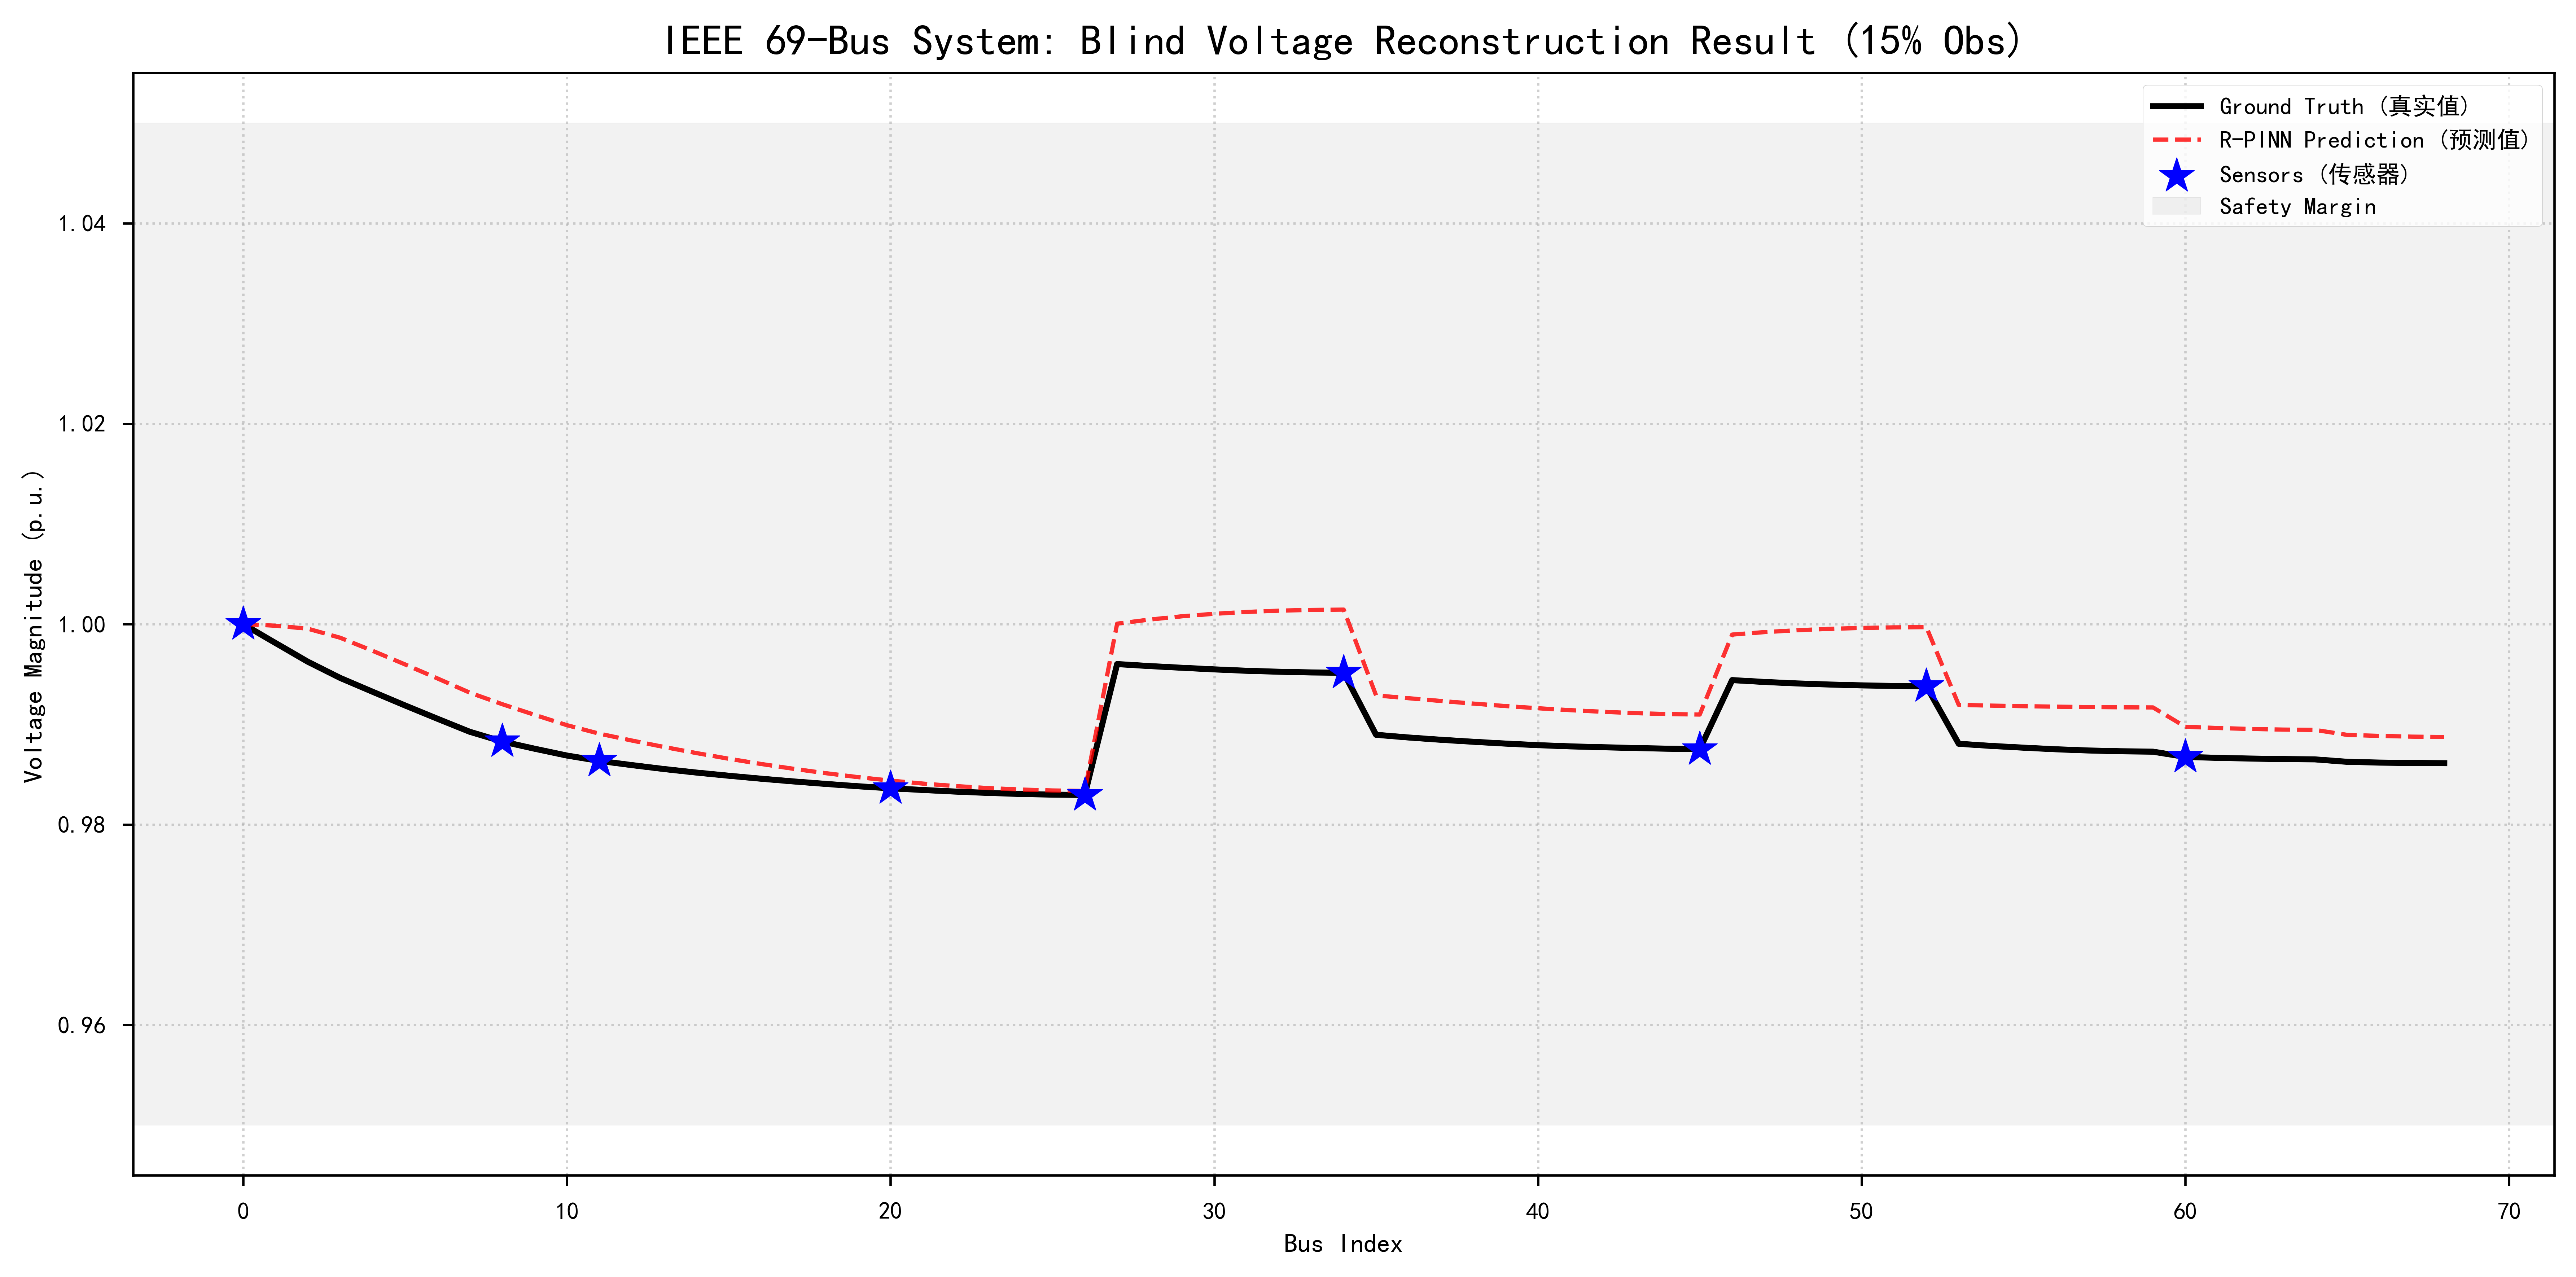

✅ 实验结束！全网 MAE: 0.003359 p.u. | 图片已保存为 69bus_reconstruction_final.png


In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==========================================
# 1. 环境配置与物理矩阵加载
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 69节点 R-PINN 点火成功 | 核心: {device}")

# 强制加载 69x69 矩阵
G_np = np.load('G_matrix_69.npy')
B_np = np.load('B_matrix_69.npy')
G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)

# ==========================================
# 2. 核心算法：对齐论文物理逻辑
# ==========================================
def calculate_physics_loss(V, theta_deg, G, B):
    """带单位转换的角度潮流方程计算"""
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    
    cos_mat = torch.cos(delta_theta)
    sin_mat = torch.sin(delta_theta)
    
    # 物理注入量计算 (P, Q)
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    
    return V * sum_p, V * sum_q

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )

    def forward(self, x):
        out = self.net(x)
        # ARS 缩放：1.0 + 0.1 * 残差
        Vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 1.0     
        Vm_pred[:, 0], theta_pred[:, 0] = 1.0, 0.0 # 锚定 Slack Bus
        return Vm_pred, theta_pred

# ==========================================
# 3. 数据载入：对齐 69 节点切片
# ==========================================
print("📂 正在进行内存级数据装载...")
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
all_data = df.values 

# 严格按照 69 维结构切片 (对应 70-1 逻辑)
V_true = all_data[:, 0:69]
Theta_true = all_data[:, 70:139] 
P_target = all_data[:, 140:209]
Q_target = all_data[:, 210:279]

X_input = np.concatenate([P_target, Q_target], axis=1) # [50000, 138]
Y_label = np.concatenate([V_true, Theta_true], axis=1) # [50000, 138]

scaler = StandardScaler()
X_norm = torch.from_numpy(scaler.fit_transform(X_input))
Y_tensor = torch.from_numpy(Y_label)

# 观测点索引：15% 观测率 (模拟盲区)
obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

train_loader = DataLoader(list(zip(X_norm, Y_tensor, 
                                  torch.from_numpy(P_target), 
                                  torch.from_numpy(Q_target))), 
                          batch_size=128, shuffle=True)

# ==========================================
# 4. 训练：双阶段权重策略 (点火！)
# ==========================================
model = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse_fn = nn.MSELoss()

print("🔥 开始 150 轮 R-PINN 深度训练...")
for epoch in range(151):
    # 论文逻辑：前 75 轮锚定数据，后 75 轮强化物理一致性
    lambda_phys = 10 if epoch < 75 else 2000
    lambda_obs = 5e5
    
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        
        # 模拟盲区输入 (只给观测点的 P, Q)
        mask_bx = torch.zeros_like(bx)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]
            mask_bx[:, idx+69] = bx[:, idx+69]
            
        v_p, t_p = model(mask_bx)
        
        # 1. 观测点误差 (锚定)
        loss_obs = mse_fn(v_p[:, obs_indices], by[:, obs_indices])
        
        # 2. 物理潮流误差
        p_c, q_c = calculate_physics_loss(v_p, t_p, G_tensor, B_tensor)
        loss_phys = mse_fn(p_c, bp) + mse_fn(q_c, bq)
        
        # 3. 电压越限惩罚 (Penalty)
        loss_pen = torch.mean(torch.relu(0.9 - v_p) + torch.relu(v_p - 1.1))
        
        total_loss = lambda_obs * loss_obs + lambda_phys * loss_phys + 1000 * loss_pen
        total_loss.backward()
        optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Total Loss: {total_loss.item():.6f} | Phys_Weight: {lambda_phys}")

# ==========================================
# 5. SCI 级绘图验证 (Figure 2 展示)
# ==========================================
print("\n📊 正在生成最终对比图...")
model.eval()
test_idx = 20 # 随机选取测试样本
with torch.no_grad():
    sample_x = X_norm[test_idx:test_idx+1].to(device)
    mask_test = torch.zeros_like(sample_x)
    for idx in obs_indices:
        mask_test[:, idx] = sample_x[:, idx]
        mask_test[:, idx+69] = sample_x[:, idx+69]
        
    v_pred, _ = model(mask_test)
    v_pred_np = v_pred.cpu().numpy().flatten()
    v_true_np = V_true[test_idx]

# 高分辨率科研绘图
plt.figure(figsize=(12, 6), dpi=600)
nodes = np.arange(69)
plt.plot(nodes, v_true_np, 'k-', label='Ground Truth (真实值)', linewidth=2)
plt.plot(nodes, v_pred_np, 'r--', label='R-PINN Prediction (预测值)', alpha=0.8)
plt.scatter(obs_indices, v_true_np[obs_indices], color='blue', marker='*', s=150, label='Sensors (传感器)', zorder=5)

plt.axhspan(0.95, 1.05, color='gray', alpha=0.1, label='Safety Margin')
plt.title(f"IEEE 69-Bus System: Blind Voltage Reconstruction Result (15% Obs)", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index"), plt.ylabel("Voltage Magnitude (p.u.)")
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('69bus_reconstruction_final.png')
plt.show()

mae = np.mean(np.abs(v_pred_np - v_true_np))
print(f"✅ 实验结束！全网 MAE: {mae:.6f} p.u. | 图片已保存为 69bus_reconstruction_final.png")